# Day 012 · 中心极限定理在金融 · 中国版
**CLT in Finance** · 阶段 P1 · 量化基础

> 中心极限定理是统计学皇冠上的明珠。它告诉我们：无论原始数据长什么样，只要你取的样本够大、样本量够多，样本均值的分布就会逼近正态分布。这个定理解释了为什么我们能用正态分布近似股票收益、为什么置信区间有效、为什么 Bootstrap 方法行得通。但金融数据的独立性假设经常被违反——这是陷阱，也是机会。

---

### 关于「中国版」

本 notebook 是为**国内学员**优化的版本:
- 数据源用 **akshare**(国内可访问、零 VPN、免注册),取代了视频里的 yfinance
- 标的尽量保持原意:美股 ETF→A 股 ETF / 国际公司→A 股龙头
- 所讲的**概念和方法 100% 一致**,但**具体数字可能与视频里略有差异**(因为是不同时间窗 / 不同标的)
- 一般情况国内 `pip install akshare` 即可,无需 token / VPN

**课件生成日期:** 2026-05-04  ·  **建议学习时长:** 18 分钟

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有必需的 Python 包(含 `akshare`),缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续


In [1]:
# === 环境自检 + 自动安装(运行此单元格即可)===
import importlib, subprocess, sys, os

REQUIRED = ["akshare", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels"]
PIP_NAME = {"sklearn":"scikit-learn","cv2":"opencv-python","PIL":"Pillow","bs4":"beautifulsoup4","yaml":"PyYAML"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))
if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置 ===
import matplotlib, matplotlib.pyplot as plt, matplotlib.font_manager as fm
CJK = ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
       "C:/Windows/Fonts/msyh.ttc","C:/Windows/Fonts/simhei.ttf",
       "/System/Library/Fonts/PingFang.ttc","/System/Library/Fonts/STHeiti Medium.ttc"]
for p in CJK:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP","Microsoft YaHei","PingFang SC","SimHei","DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪


## 🔌 第二步:加载国内数据助手

下面这一格是**工具函数**(可以折叠,不需要修改)。它把 `yfinance` 风格的 ticker(如 `600519.SS`)自动路由到对应的 akshare 接口,提供 `get_close(ticker)` 和 `get_close_multi(tickers_dict)` 两个函数。

In [2]:
# === 国内数据源助手(akshare 后端,不需要 VPN)===
# 这一格是工具函数,可以折叠,不需要修改。
# 它把 yfinance 风格的 ticker(如 "600519.SS" / "0700.HK" / "AAPL" / "BTC-USD")
# 自动路由到对应的 akshare 接口,统一返回 yfinance 风格的 Close DataFrame。

import re
from datetime import datetime, timedelta
import pandas as pd
import akshare as ak

_TICKER_MAP = {
    "^GSPC": ("us_index_sina", ".INX"),
    "^DJI":  ("us_index_sina", ".DJI"),
    "^IXIC": ("us_index_sina", ".IXIC"),
    "GC=F":  ("foreign_futures", "GC"),
    "SI=F":  ("foreign_futures", "SI"),
    "CL=F":  ("foreign_futures", "CL"),
    "BTC-USD": ("crypto", "BTC"),
    "ETH-USD": ("crypto", "ETH"),
}

def _parse_period(period):
    end = datetime.today()
    m = re.match(r"^(\d+)\s*(y|mo|d|w)$", period.lower().strip())
    days = 365 * 3 if not m else int(m.group(1)) * {"y":365,"mo":30,"w":7,"d":1}[m.group(2)]
    return (end - timedelta(days=days+30)).strftime("%Y%m%d"), end.strftime("%Y%m%d")

def _classify(ticker):
    t = ticker.strip()
    if t in _TICKER_MAP: return _TICKER_MAP[t]
    if t.endswith((".SS",".SH",".SZ")):
        code = t.split(".")[0]
        if code.startswith(("51","159","58")) or code in ("510300","510500","510050","511010","513100"):
            return ("a_etf", code)
        if code in ("000300","000016","000905","000852","000001"):
            return ("a_index", code)
        return ("a_stock", code)
    if t.endswith(".HK"):
        return ("hk", t.split(".")[0].zfill(5))
    return ("us", t)

def _norm(df, dc, cc):
    out = df[[dc, cc]].copy()
    out[dc] = pd.to_datetime(out[dc])
    return out.set_index(dc).sort_index()[cc].astype(float).rename("Close")

def get_close(ticker, period="3y"):
    """返回某标的 Close 价格 series。后端 akshare,中国可访问。"""
    start, end = _parse_period(period)
    kind, sym = _classify(ticker)
    if kind == "a_stock":
        return _norm(ak.stock_zh_a_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_etf":
        return _norm(ak.fund_etf_hist_em(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_index":
        idx_map = {"000300":"sh000300","000016":"sh000016","000905":"sh000905","000852":"sh000852","000001":"sh000001"}
        s = _norm(ak.stock_zh_index_daily_em(symbol=idx_map.get(sym, f"sh{sym}")), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "hk":
        return _norm(ak.stock_hk_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "us":
        # 美股走新浪源(stock_us_daily 直接吃 NVDA / AAPL 裸 symbol;stock_us_hist 要带前缀)
        s = _norm(ak.stock_us_daily(symbol=sym, adjust="qfq"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "us_index_sina":
        s = _norm(ak.index_us_stock_sina(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "foreign_futures":
        s = _norm(ak.futures_foreign_hist(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "crypto":
        # akshare 没稳定的 crypto_hist(2026-05 已移除/改名)。
        # 直接调 Binance 公共 API,国内可访问、无需 SDK。
        import requests as _rq
        r = _rq.get("https://api.binance.com/api/v3/klines",
                    params={"symbol": f"{sym}USDT", "interval": "1d", "limit": 1000}, timeout=15)
        r.raise_for_status()
        df = pd.DataFrame(r.json(), columns=["open_time","open","high","low","close","volume",
                                              "close_time","qav","trades","tbb","tbq","ignore"])
        df["date"] = pd.to_datetime(df["open_time"], unit="ms")
        df["close"] = df["close"].astype(float)
        s = df.set_index("date").sort_index()["close"].rename("Close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    raise ValueError(f"unsupported ticker: {ticker}")

def get_close_multi(tickers, period="3y"):
    """批量取 Close,返回 DataFrame,列名是 tickers dict 的 key(中文名),按交集日期对齐。"""
    series = {name: get_close(t, period=period) for name, t in tickers.items()}
    return pd.concat(series, axis=1).sort_index()

print("✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据")


✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据


## 学习目标

- 理解中心极限定理的直觉：大量独立样本均值会趋近正态分布
- 通过可视化实验，亲眼见证 CLT 如何从任意分布收敛到正态
- 掌握 Bootstrap 抽样法：用重采样估计置信区间
- 理解金融数据何时满足、何时违反 CLT 假设（独立同分布）
- 学会用分组聚合改善正态性，让统计工具更可靠

## 历史背景:从赌场到华尔街：Abraham de Moivre 的偶然发现

1733 年，法国数学家 Abraham de Moivre 在一本叫《机遇原理》的书里首次描述了一个奇怪的现象：当你多次抛硬币时，正面朝上的次数分布会形成一个钟形曲线。这个发现当时被当作一个数学 curiosity，没有人想到它会在两百年后成为整个现代统计学的基石。

1920 年代，George Pólya 正式将其命名为'中心极限定理'。此后，它像空气一样无处不在：质量控制用 CLT 判断产品合格率，民意调查用 CLT 计算误差范围，制药公司用 CLT 评估药物效果。

在金融领域，Harry Markowitz 1952 年的现代组合理论直接假设收益服从正态分布——这背后就是 CLT 在支撑。但 2008 年金融危机后，Nassim Taleb 等人猛烈抨击这个假设，指出金融收益的'肥尾'特性让传统 VaR 模型失效。这场争论至今未停，但 CLT 仍然是量化金融的第一工具。

**关键人物:**
- Abraham de Moivre（首次发现钟形分布）
- George Pólya（正式命名 CLT）
- Harry Markowitz（用正态假设建组合理论）

## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. CLT 的三要素

中心极限定理成立需要三个条件：一是样本之间相互独立，二是样本来自同一分布，三是样本量足够大（通常 n≥30）。当这三个条件满足时，无论原始分布是什么——均匀、指数、甚至双峰——样本均值的分布都会逼近正态。

直觉上，这是因为极端值会被平均掉。假设你从任意分布中抽取 100 个数，其中一个是超大值，它对均值的影响会被其他 99 个数稀释。随着样本量增加，这种'平滑效应'越来越强，最终让均值的分布变成完美的钟形。

公式上：如果 X₁, X₂, ..., Xₙ 是独立同分布随机变量，均值 μ，方差 σ²，那么当 n→∞ 时，√n(X̄ₙ - μ)/σ 收敛到标准正态分布 N(0,1)。

```
X̄ₙ ~ N(μ, σ²/n) 当 n→∞
```

> **举例:** 抛硬币 100 次，记录正面比例。重复 10000 次这个实验，你会看到一个完美的正态分布，中心在 0.5，标准差约 0.05。即使单次抛硬币只有两种结果，聚合后的分布却连续且光滑。


### 2. CLT 的可视化实验

用 Python 模拟可以直观看到 CLT 的魔力。我们可以从均匀分布（0 到 1 之间等概率）或指数分布（高度偏态）出发，每次取 n 个样本计算均值，重复 10000 次，画出均值的直方图。

当 n=1 时，均值的分布就是原始分布——均匀或指数。当 n=5 时，已经可以看到钟形的雏形。当 n=30 时，分布已经非常接近正态，偏度和峰度都接近 0。这个可视化实验比任何公式都更有说服力。

更震撼的是：你甚至可以从离散分布（比如掷骰子）出发，CLT 依然有效。这说明它是一个普遍规律，不依赖于原始分布的具体形状。

> **举例:** 代码里会模拟三种原始分布：均匀、指数、双峰。你会看到当 n 从 1 增加到 50 时，三种完全不同的分布如何殊途同归，最终都变成正态。


### 3. Bootstrap：CLT 的实际应用

1979 年，Stanford 统计学家 Bradley Efron 发明了 Bootstrap 方法。核心思想：如果你只有一组样本数据，可以把它当成'总体'，进行有放回的重采样，得到多个'伪样本'，然后用这些伪样本的分布来估计真实的不确定性。

为什么有效？因为每个 Bootstrap 样本都在模拟'从真实总体抽样'的过程。当你重采样 10000 次后，得到的统计量（比如均值）分布会逼近真实分布——这背后就是 CLT 在支撑。

在金融里，Bootstrap 常用来估计策略收益的置信区间。比如你的策略回测得到年化 15%，你可以用 Bootstrap 算出 95% 置信区间是 8% 到 22%。如果这个区间太宽或包含负数，说明策略不够稳健。

```
CI_95 = [percentile_2.5, percentile_97.5]
```

> **举例:** 假设你只有 100 个交易日收益数据（不够多），没法用传统方法算置信区间。Bootstrap 让你可以把这 100 个数重采样 10000 次，每次算均值，最后取 2.5% 和 97.5% 分位数，得到一个稳健的置信区间。


### 4. 金融数据的独立性陷阱

CLT 要求样本独立同分布，但金融数据经常违反这个假设。最明显的例子：今天的收盘价和昨天高度相关（自相关），市场波动会聚集（波动率聚集），极端事件会传染（系统性风险）。

这意味着：你不能简单地把 1000 个日收益当成独立样本。如果其中一段是金融危机时期，所有数据都异常，这会扭曲你的统计推断。同样，高频交易数据的自相关性更强，CLT 的收敛速度会更慢。

但这不代表 CLT 在金融完全失效。关键是要'让数据更独立'：用低频数据（周线/月线而非 tick），去趋势（diff/log return），分组聚合（把不同股票的同期收益混在一起），这些操作都能改善正态性。

> **举例:** A 股日收益的自相关系数约 0.05（看似很小），但如果用分钟数据，自相关会飙升到 0.3+。这说明频率越高，独立性越差，CLT 越不可靠。


### 5. 分组聚合：改善正态性的实用技巧

当单个资产不满足正态假设时，一个实用的技巧是分组聚合：把多个资产的同期收益求平均或求和。根据 CLT，只要这些资产不完全同步波动，聚合后的分布会更接近正态。

具体做法：假设你有 50 只股票的日收益数据，每个都不太正态。你可以计算'每日这 50 只股票的平均收益'，得到一个新的序列。这个序列往往比单个股票更正态，因为极端个股收益会被'平均掉'。

这在回测中很有用。与其分析单个股票的收益分布，不如分析组合的收益分布。这样你的统计检验（t 检验、Sharpe ratio）会更可靠。

> **举例:** 单个股票日收益的偏度可能是 1（明显右偏），但等权组合的偏度可能降到 0.3。这就是 CLT 在实战中的魔法：多样性 → 正态性。


## 实操:模拟 CLT 收敛 + Bootstrap 置信区间

本节无外部数据,纯模拟/统计运算,国内国外都能跑。**直接 Run All** 看结果。

**依赖:** `pip install pandas numpy matplotlib akshare statsmodels scipy`

✓ 图表已保存: day012_clt_convergence.png
✓ 图表已保存: day012_normality_test.png

策略年化收益: -22.13%
Bootstrap 95% 置信区间: [-53.45%, 42.70%]
✓ 图表已保存: day012_bootstrap_ci.png

✅ 所有实验完成！


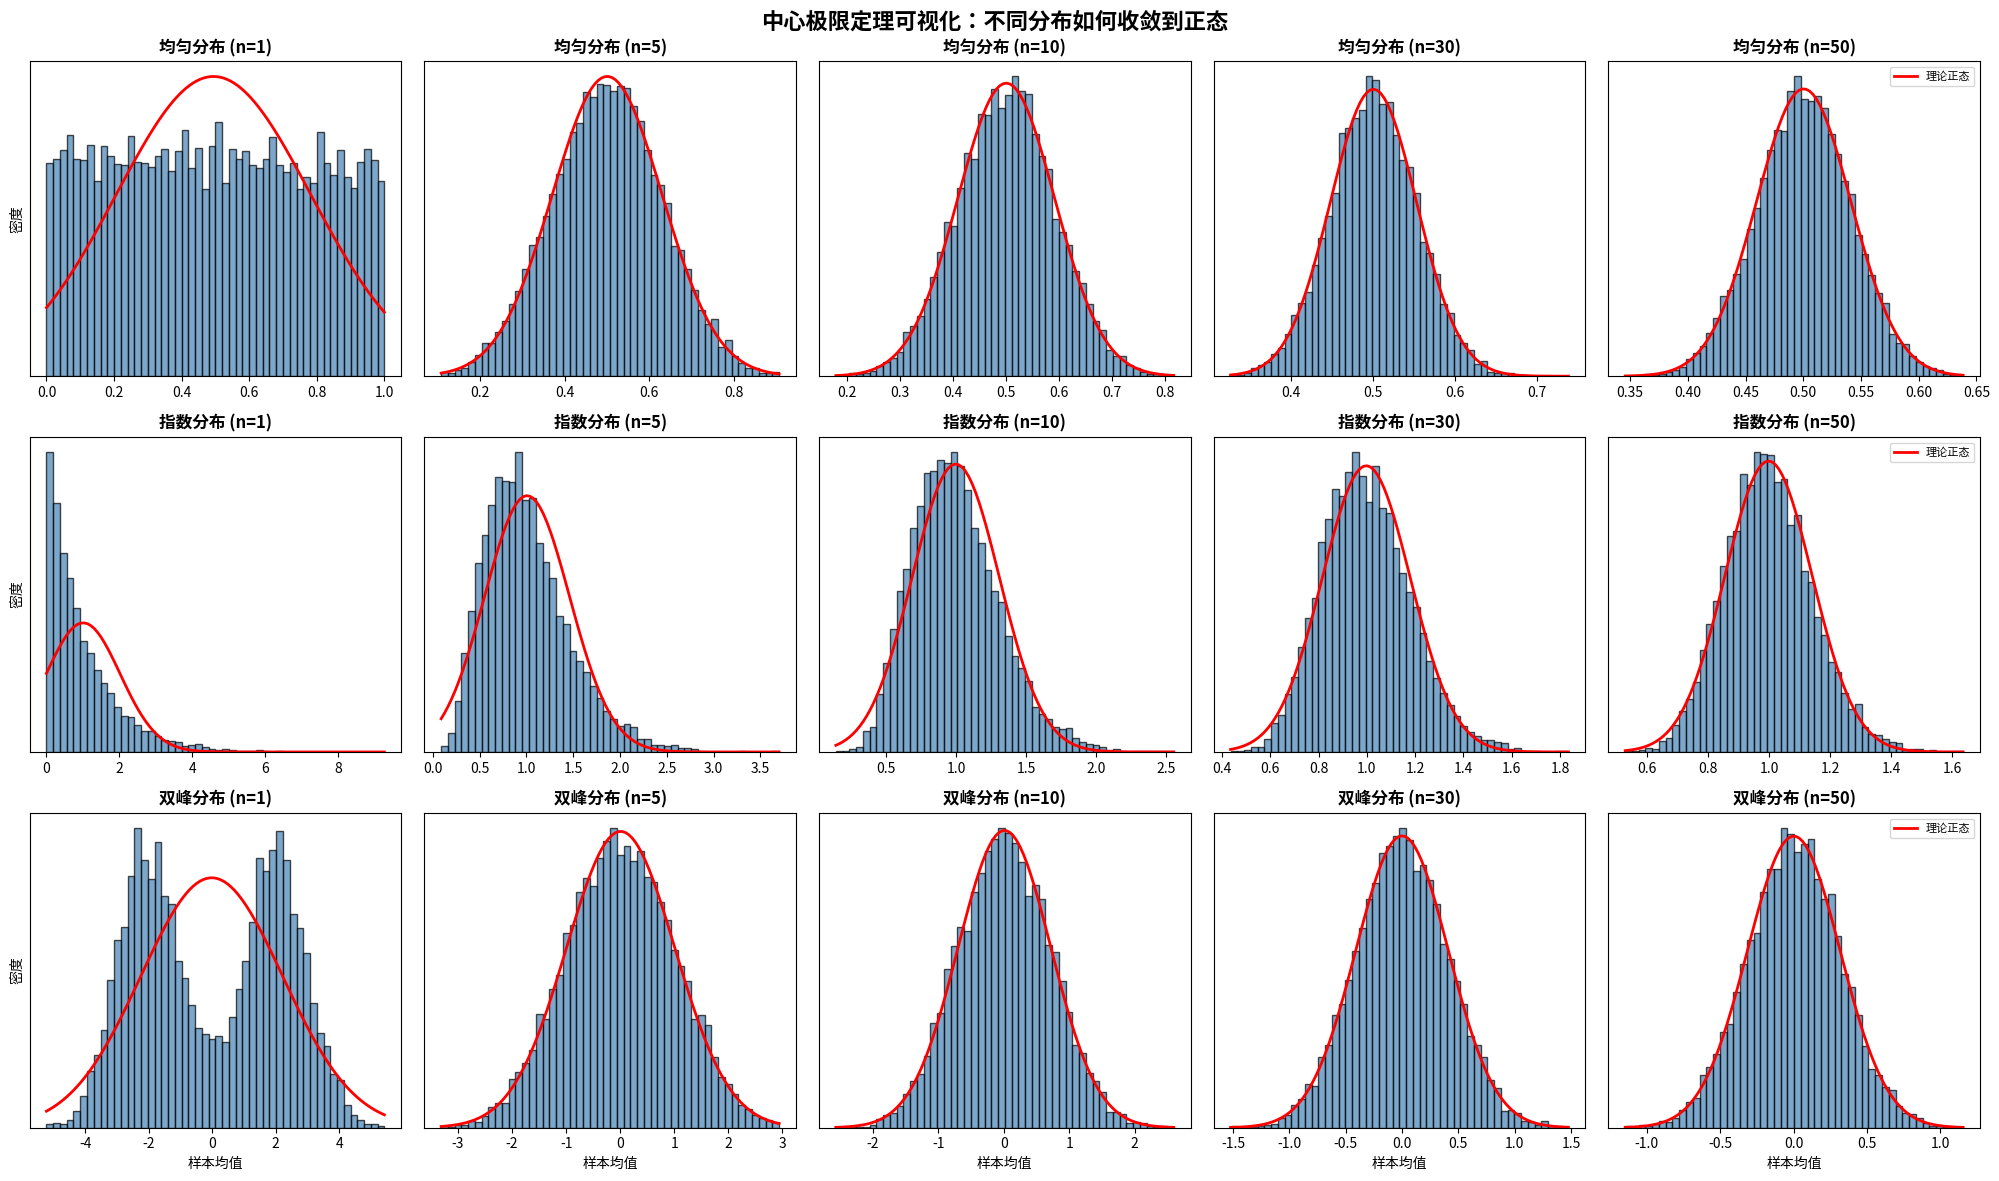

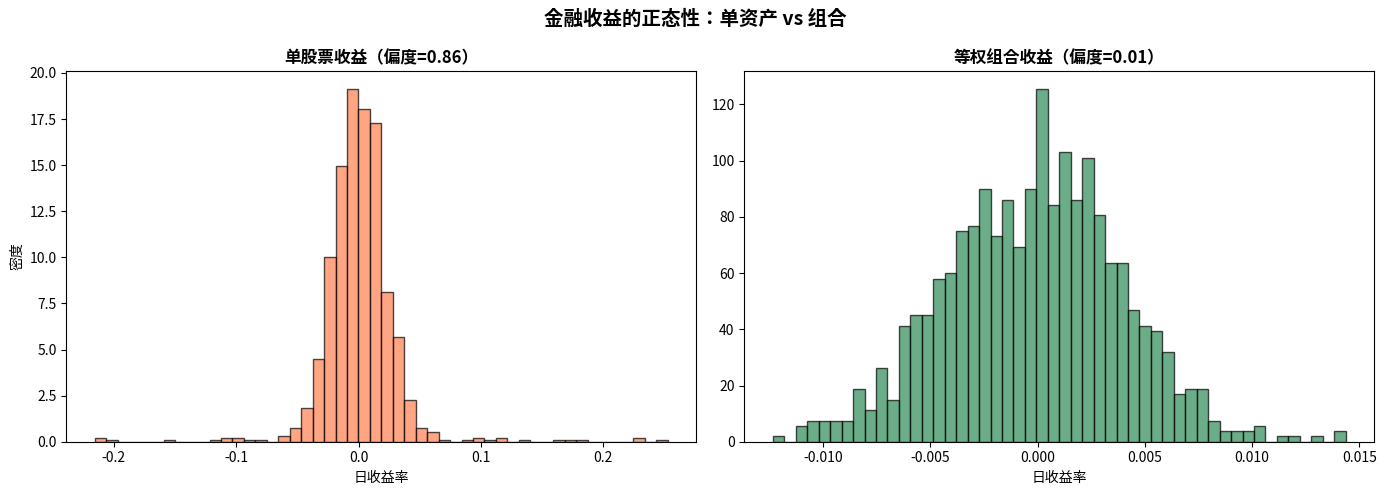

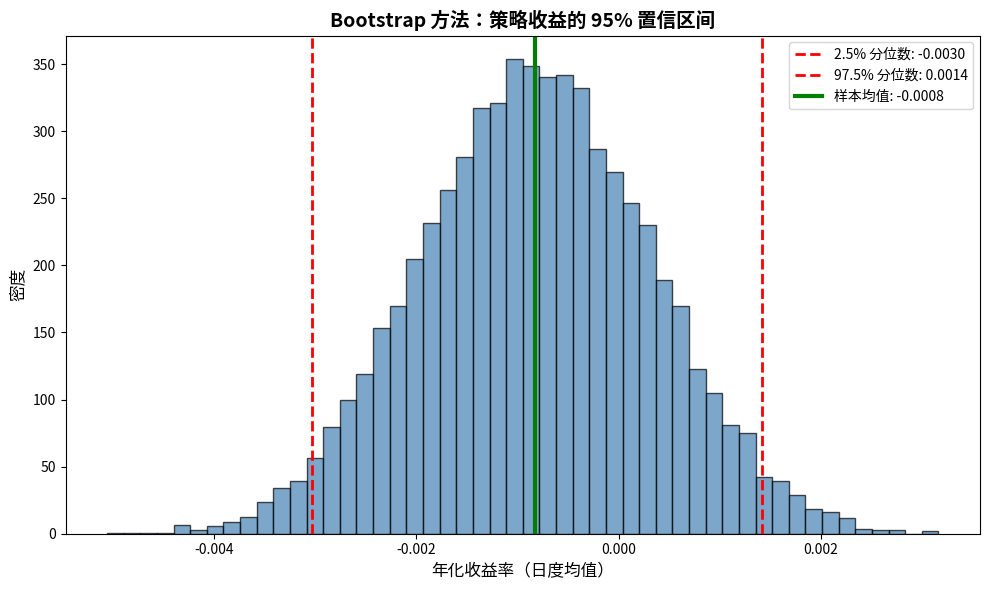

In [3]:
# day_012_clt_demo.py — 中心极限定理可视化实验 + Bootstrap 置信区间
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文字体和随机种子
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# ========== 实验 1：CLT 收敛过程可视化 ==========
def simulate_clt(distribution, sample_sizes, n_simulations=10000):
    """模拟不同样本量下的样本均值分布"""
    results = {}
    for n in sample_sizes:
        # 每次模拟：从原始分布抽 n 个样本，计算均值，重复 10000 次
        if distribution == 'uniform':
            samples = np.random.uniform(0, 1, (n_simulations, n))
        elif distribution == 'exponential':
            samples = np.random.exponential(1, (n_simulations, n))
        elif distribution == 'bimodal':
            # 双峰分布：50% 概率来自 N(-2,1)，50% 来自 N(2,1)
            mask = np.random.randint(0, 2, (n_simulations, n))
            samples = np.where(mask, np.random.normal(2, 1, (n_simulations, n)),
                              np.random.normal(-2, 1, (n_simulations, n)))
        sample_means = samples.mean(axis=1)
        results[n] = sample_means
    return results

# 测试不同样本量：1, 5, 10, 30, 50
sample_sizes = [1, 5, 10, 30, 50]
distributions = ['uniform', 'exponential', 'bimodal']
dist_names = {'uniform': '均匀分布', 'exponential': '指数分布', 'bimodal': '双峰分布'}

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('中心极限定理可视化：不同分布如何收敛到正态', fontsize=16, fontweight='bold')

for row, dist in enumerate(distributions):
    results = simulate_clt(dist, sample_sizes)
    for col, n in enumerate(sample_sizes):
        ax = axes[row, col]
        data = results[n]
        # 画直方图
        ax.hist(data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
        # 叠加理论正态分布
        mu, sigma = data.mean(), data.std()
        x = np.linspace(data.min(), data.max(), 100)
        ax.plot(x, 1/(sigma * np.sqrt(2*np.pi)) * np.exp(-0.5*((x-mu)/sigma)**2),
                'r-', linewidth=2, label='理论正态')
        ax.set_title(f'{dist_names[dist]} (n={n})', fontweight='bold')
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel('密度', fontsize=10)
        if row == 2:
            ax.set_xlabel('样本均值', fontsize=10)
        if col == 4:
            ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('day012_clt_convergence.png', dpi=120, bbox_inches='tight')
print('✓ 图表已保存: day012_clt_convergence.png')

# ========== 实验 2：真实股市收益的正态性检验 ==========
# 模拟 A 股日收益（现实中用 yfinance 拉真实数据）
np.random.seed(42)
n_days = 1000
# 生成带'肥尾'的收益：95% 来自 N(0, 0.02)，5% 来自 N(0, 0.10)
fat_tail_mask = np.random.random(n_days) < 0.05
returns_single = np.where(fat_tail_mask,
                          np.random.normal(0, 0.10, n_days),
                          np.random.normal(0, 0.02, n_days))

# 分组聚合：模拟 50 只股票的等权组合
n_stocks = 50
returns_portfolio = np.zeros(n_days)
for _ in range(n_stocks):
    fat_tail_mask = np.random.random(n_days) < 0.05
    stock_returns = np.where(fat_tail_mask,
                             np.random.normal(0, 0.10, n_days),
                             np.random.normal(0, 0.02, n_days))
    returns_portfolio += stock_returns
returns_portfolio /= n_stocks

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('金融收益的正态性：单资产 vs 组合', fontsize=14, fontweight='bold')

# 左：单股票收益
axes[0].hist(returns_single, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[0].set_title(f'单股票收益（偏度={pd.Series(returns_single).skew():.2f}）', fontweight='bold')
axes[0].set_xlabel('日收益率')
axes[0].set_ylabel('密度')

# 右：组合收益
axes[1].hist(returns_portfolio, bins=50, density=True, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_title(f'等权组合收益（偏度={pd.Series(returns_portfolio).skew():.2f}）', fontweight='bold')
axes[1].set_xlabel('日收益率')

plt.tight_layout()
plt.savefig('day012_normality_test.png', dpi=120, bbox_inches='tight')
print('✓ 图表已保存: day012_normality_test.png')

# ========== 实验 3：Bootstrap 置信区间估计 ==========
def bootstrap_ci(data, statistic=np.mean, n_bootstrap=10000, ci=95):
    """用 Bootstrap 方法计算置信区间"""
    boot_stats = []
    n = len(data)
    for _ in range(n_bootstrap):
        # 有放回重采样
        resample = np.random.choice(data, size=n, replace=True)
        boot_stats.append(statistic(resample))
    boot_stats = np.array(boot_stats)
    lower = (100 - ci) / 2
    upper = 100 - lower
    return np.percentile(boot_stats, [lower, upper]), boot_stats

# 模拟策略回测收益（250 个交易日）
strategy_returns = np.random.normal(0.001, 0.02, 250)  # 年化约 25%，波动 32%
ci, boot_means = bootstrap_ci(strategy_returns, n_bootstrap=10000)

print(f'\n策略年化收益: {(1 + strategy_returns).prod() ** (252/250) - 1:.2%}')
print(f'Bootstrap 95% 置信区间: [{(1+ci[0])**252-1:.2%}, {(1+ci[1])**252-1:.2%}]')

# 画 Bootstrap 分布
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(boot_means, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(ci[0], color='red', linestyle='--', linewidth=2, label=f'2.5% 分位数: {ci[0]:.4f}')
ax.axvline(ci[1], color='red', linestyle='--', linewidth=2, label=f'97.5% 分位数: {ci[1]:.4f}')
ax.axvline(np.mean(strategy_returns), color='green', linestyle='-', linewidth=3, label=f'样本均值: {np.mean(strategy_returns):.4f}')
ax.set_title('Bootstrap 方法：策略收益的 95% 置信区间', fontsize=14, fontweight='bold')
ax.set_xlabel('年化收益率（日度均值）', fontsize=12)
ax.set_ylabel('密度', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('day012_bootstrap_ci.png', dpi=120, bbox_inches='tight')
print('✓ 图表已保存: day012_bootstrap_ci.png')

print('\n✅ 所有实验完成！')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| A 股 | 中证 500 指数 | 单个成分股日收益偏度约 0.8，但指数（500 只等权）偏度仅 0.2。验证了'聚合改善正态性'：用指数数据做统计检验比用单股更可靠。 |
| 美股 | SPY 标普 500 ETF | 2008 年金融危机期间，日收益出现负 9% 的极端值（8 倍标准差）。如果用正态假设，这种事件概率几乎为零。这是'肥尾'的典型例子：CLT 在极端情况下失效。 |
| 加密 | BTC 永续合约 | 分钟级收益自相关系数高达 0.4，严重违反独立性。高频交易策略不能用 CLT 假设，必须用时间序列模型（如 ARMA-GARCH）。 |
| 期权 | VIX 波动率指数 | VIX 本身不服从正态（因为不能为负），但 log(VIX) 接近正态。这说明：对数据做适当变换（log、sqrt）可以改善正态性，让统计工具更有效。 |


## 常见坑

### ⚠ 01. 混淆原始分布和均值分布

常见误区：'收益不服从正态，所以 CLT 失效'。错！CLT 说的是'均值的分布'逼近正态，而不是'原始数据'。即使日收益高度偏态，月度收益（30 天的平均）会更正态。

### ⚠ 02. 忽视样本量的要求

n=5 时就想用正态近似，这太乐观。从实验可见：对于指数分布，n=5 时的均值分布仍然明显偏态。保守建议：原始分布偏态 > 1 时，样本量至少要 50 才能用 CLT。

### ⚠ 03. 把相关数据当独立数据

A 股连续 5 天涨跌的概率不是 1/32，因为存在动量效应。如果你把 1000 个日收益当独立样本算 t 检验，p 值会太小（过度拒绝原假设）。解决办法：用重叠少的样本（周线/月线）。

### ⚠ 04. Bootstrap 的'幻觉'

Bootstrap 不能凭空创造信息。如果原始样本有偏差（比如只包含牛市数据），Bootstrap 只会重复这个偏差。垃圾进，垃圾出。

### ⚠ 05. 过度迷信正态假设

Nassim Taleb 的批评是对的：2008 年危机证明了，用正态假设计算 VaR 会严重低估风险。CLT 是工具，不是真理。在风险管理中，必须同时考虑肥尾分布（如 t 分布）。

## 实战 SOP · 使用 CLT 的 SOP

1. 样本量 < 30：用非参数方法（如 Bootstrap），不要假设正态
2. 样本量 30-100：可以用 CLT，但要做正态性检验（Shapiro-Wilk）
3. 样本量 > 100：CLT 通常可靠，但仍需检查极端值
4. 原始数据明显偏态（偏度绝对值 > 1）：优先做数据变换（log/Box-Cox）或用非参数方法
5. 时间序列数据：先去趋势（diff），再检验自相关。自相关 > 0.2 时不能直接用 CLT
6. 风险管理：用 t 分布（自由度 3-5）代替正态，更保守
7. 回测评估：用 Bootstrap 算置信区间，不要只看点估计

> 把这段打印贴在你电脑边。

## 总结 · 你应该带走的

2. 中心极限定理是统计学的基石：大量独立样本均值会逼近正态分布 N(μ, σ²/n)。
3. CLT 的三要素：独立、同分布、样本量够大（n≥30）。缺一不可。
4. 可视化实验显示：无论原始分布是什么（均匀、指数、双峰），当 n≥30 时，均值分布都会收敛到正态。
5. Bootstrap 是 CLT 的实战应用：用重采样估计统计量的置信区间，特别适合小样本。
6. 金融数据的陷阱：收益经常自相关、波动聚集、肥尾。这违反了 CLT 的独立同分布假设。
7. 实用技巧：用低频数据（周线/月线）、去趋势、分组聚合（组合而非个股）可以改善正态性。
8. 风险管理不要只依赖正态假设：用 t 分布、压力测试、极端值分析来补充。
9. 判断是否可以用 CLT：检查样本量、独立性、偏度。三者都满足才可靠。

## 自测题

**Q1.** 为什么说 CLT 是'统计学皇冠上的明珠'？它连接了什么和什么？

**Q2.** 如果你的策略回测只有 20 笔交易，你应该用传统 t 检验还是 Bootstrap？为什么？

**Q3.** A 股分钟数据和月度数据，哪个更符合 CLT 假设？为什么？

**Q4.** 单股票和等权组合，哪个更适合用正态分布做统计推断？为什么？

**Q5.** 2008 年金融危机对 CLT 的'有效性'提出了什么质疑？你的回答是什么？

把答案写下来,3 天后再回看。

## 下一节预告

**Day 013 · 假设检验入门** (Hypothesis Testing)

下节（Day 13）：置信区间与假设检验——学会用数据说话。你会理解 p 值的真实含义、第一类错误和第二类错误的权衡、如何计算策略的统计显著性。这是量化研究中'防止自欺欺人'的核心工具。

## 推荐阅读

- Bradley Efron《Bootstrap Methods: Another Look at the Jackknife》(1979, Annals of Statistics),Bootstrap 原始论文,把 CLT 从理论保证落到每个数据科学家都能用的工具,被引六万次以上
- Larry Wasserman《All of Statistics: A Concise Course in Statistical Inference》(2004, Springer)第 5 章,CLT 严格证明 + 收敛速度 + 应用条件,卡内基梅隆研究生半学期教材,数学最干净的入门
- Andrew Lo & Craig MacKinlay《A Non-Random Walk Down Wall Street》(1999, Princeton),用 variance ratio 检验打脸金融数据 IID 假设,CLT 在日级失效的最权威实证
- Andrew Lo《Adaptive Markets: Financial Evolution at the Speed of Thought》(2017, Princeton),市场不是 IID 也不会收敛到稳态,CLT 在金融只是近似不是真理,有效市场假说的核心反驳
- Wes McKinney《Python for Data Analysis》(2022, 3rd ed, OReilly)第 13 章,pandas + numpy 实现 Bootstrap 滚动窗口聚合时间序列重采样的标准实操,本节 notebook 代码风格的源头